# Coursework - Rowan d'Auria (rd761)

### TODO
- Data Exploration

## Data Exploration
> _Become one with the data_

MoonsDataset(name='train', n=800) MoonsDataset(name='val', n=100) MoonsDataset(name='test', n=100)
=== train (800 samples, 2 classes) ===
  Class counts: {0: 385, 1: 415}
  x1: mean=0.521, std=0.874, range=[-1.127, 2.067]
  x2: mean=0.231, std=0.491, range=[-0.610, 1.201]
  class_0: mean=[0.001268340740352869, 0.6216179728507996], std=[0.717052698135376, 0.3202870488166809]
  class_1: mean=[1.0032110214233398, -0.13077937066555023], std=[0.7164219617843628, 0.31061533093452454]

  Duplicates: 0, NaNs: 0
  Correlation(x1, x2): -0.4347

=== val (100 samples, 2 classes) ===
  Class counts: {0: 56, 1: 44}
  x1: mean=0.461, std=0.796, range=[-1.003, 2.029]
  x2: mean=0.334, std=0.541, range=[-0.579, 1.078]
  class_0: mean=[0.05057208612561226, 0.7256950736045837], std=[0.6229149699211121, 0.28358083963394165]
  class_1: mean=[0.9824522137641907, -0.16392913460731506], std=[0.6777079105377197, 0.34579598903656006]

  Duplicates: 0, NaNs: 0
  Correlation(x1, x2): -0.5334

=== test (100 sample

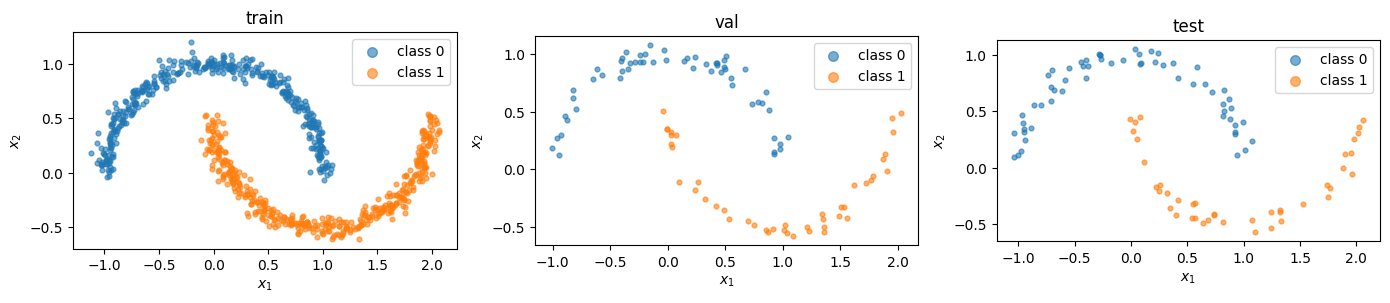

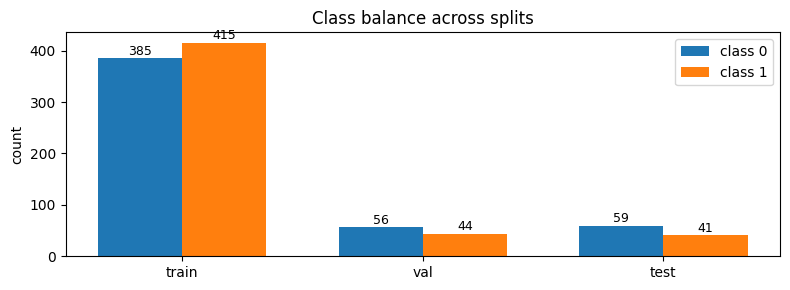

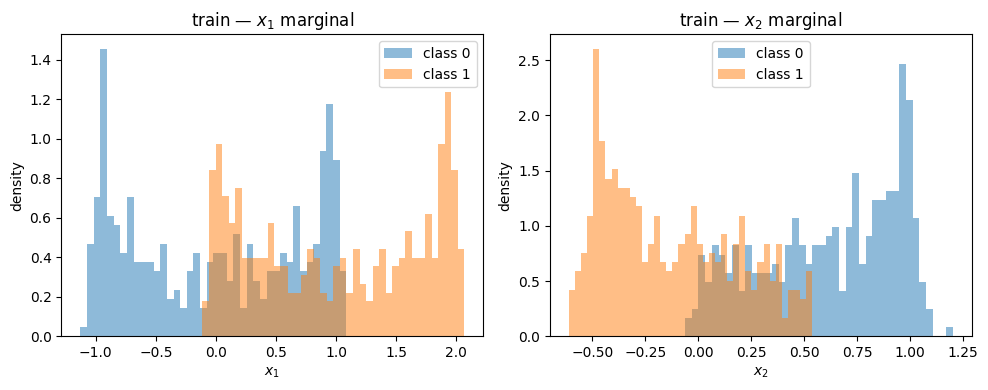

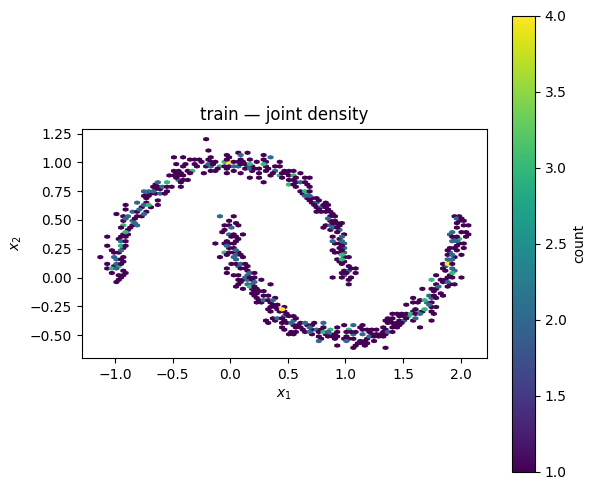

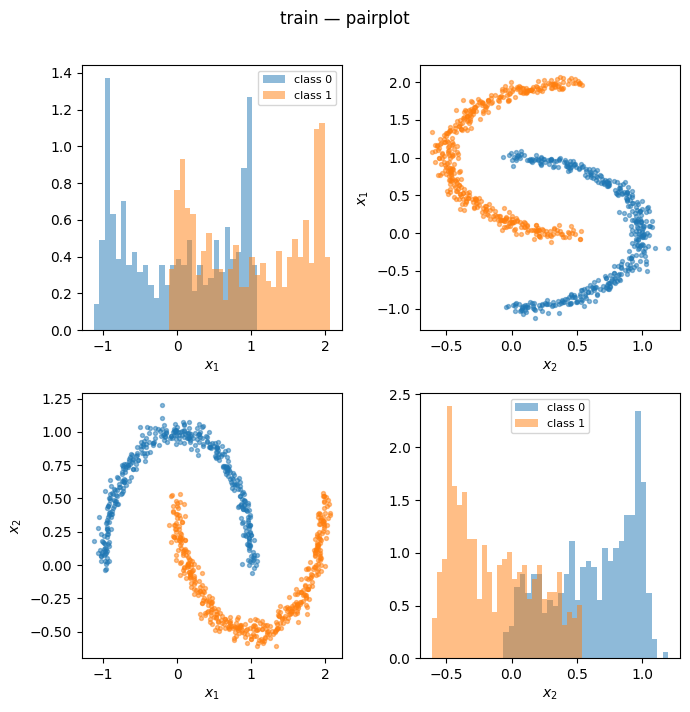

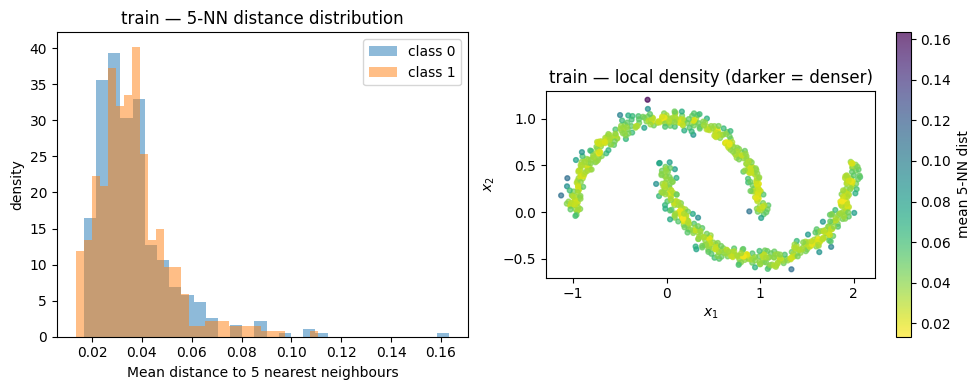

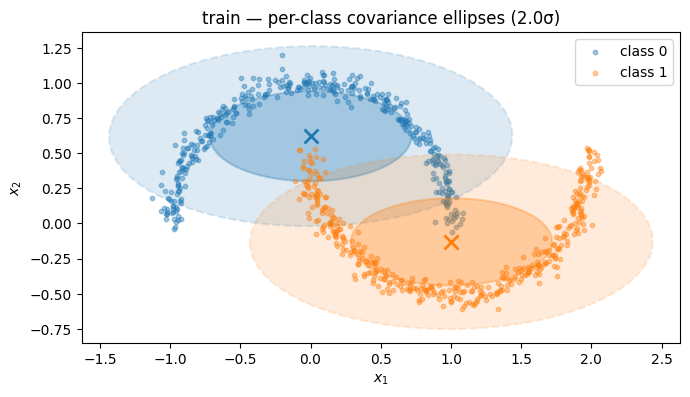

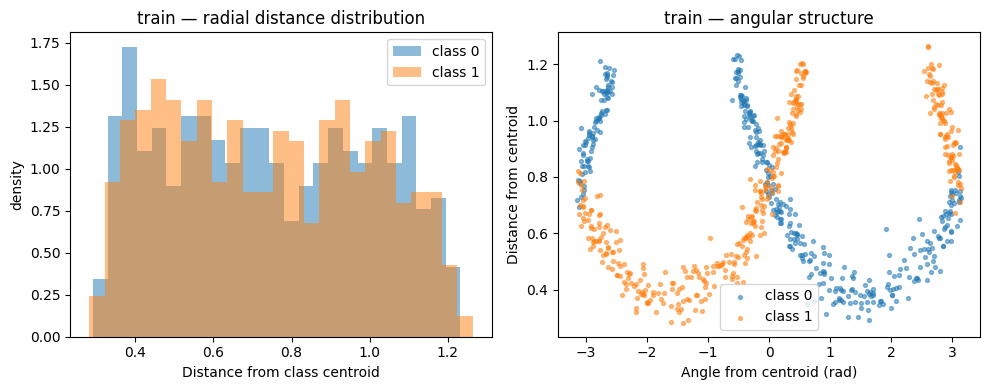

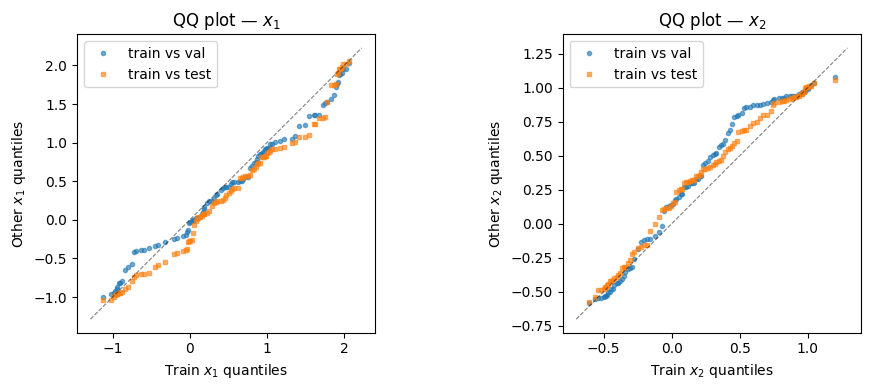

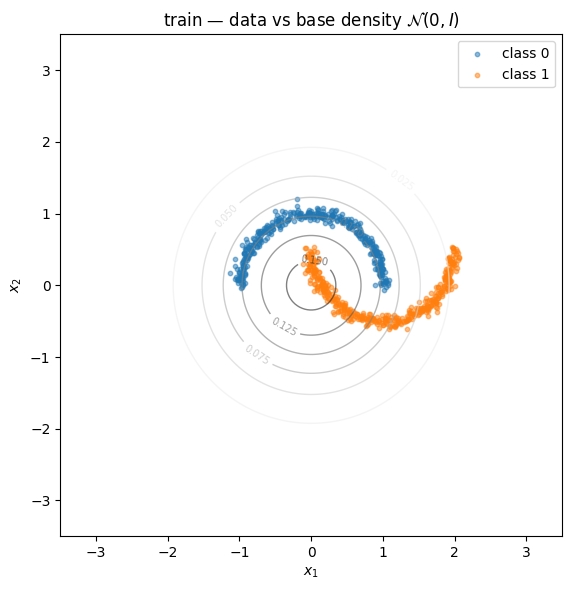

In [1]:
from flows import *

# Load all splits
splits = MoonsSplits.load("data")
print(splits.train, splits.val, splits.test)

# --- Full statistical report (now includes KS tests) ---
full_report(splits)

# --- Visualisations ---

# 1. Scatter plots of each split side-by-side
scatter_splits(splits)

# 2. Class balance across splits
class_balance_bar(splits.train, splits.val, splits.test)

# 3. Marginal histograms (per-class) for training data
marginal_histograms(splits.train)

# 4. Joint density estimate
joint_kde(splits.train)

# 5. Pairplot
pairplot(splits.train)

# 6. k-NN distances — local density variation
knn_distances(splits.train, k=5)

# 7. Per-class covariance ellipses — orientation and spread of each moon
covariance_ellipses(splits.train)

# 8. Radial distance from class centroids — reveals arc structure
radial_from_centroids(splits.train)

# 9. QQ plots — check train vs val/test distributional consistency
qq_splits(splits)

# 10. Base density overlay — how far the data is from N(0,I)
_ = base_density_overlay(splits.train)

### Data Exploration Observations
- Interesting grouping
- Add more!!!

## Q1 - A Mini Normalizing Flow [30 marks]

In this coursework you will implement and train an affine coupling flow (chapter 16 of Prince, *Understanding Deep Learning*) on a 2D dataset.

### (a)

Implement an affine coupling transform for a 2D vector $h = [h_1 \; h_2]^\top$. Implement this in PyTorch. A single coupling layer keeps one component fixed and transforms the other:

$$h_1' = h_1, \qquad h_2' = h_2 \odot \exp[s[h_1]] + t[h_1],$$

where $s[\cdot]$ and $t[\cdot]$ are learned functions, and $\odot$ denotes elementwise multiplication. The $\exp[\cdot]$ is also applied elementwise. In this coursework, implement $s[\cdot]$ and $t[\cdot]$ using a single MLP applied to the masked input, with architecture

$$\text{Linear}(D \to H) \;\to\; \text{ReLU} \;\to\; \text{Linear}(H \to 2D),$$

then split the output into $s[\cdot]$ and $t[\cdot]$. Use at most `hidden=128` and at most `n_layers=8` in your submitted model. For numerical stability you should bound the scale output using $s \leftarrow \tanh[s]$.

Implement both directions:

- the forward map $f[z]$ used for sampling (base $\to$ data), and
- the inverse map $f^{-1}[x]$ used for evaluating $\log p[x]$ (data $\to$ base).

Your code must return both the transformed output and the log-determinant of the Jacobian for that direction.

### (b)

Build a flow by stacking $K$ coupling layers with alternating masks (each dimension should be transformed in some layers). Let the base density be standard normal $p[z] = \mathcal{N}(0, I)$. Implement a function that evaluates $\log p[x]$ for a batch of points.

Below we define an `AffineCouplingLayer` that keeps one component fixed and transforms the other via an internal MLP, and a `Flow` that stacks $K$ such layers with alternating masks.

In [1]:
from flows import AffineCouplingLayer, Flow

### Q1(c) - Correctness Checks

Two checks:

1. **Invertibility**: for every point in `data/moons_train.csv`, compute $z = f^{-1}[x]$, reconstruct $\hat{x} = f[z]$, and report the maximum absolute reconstruction error over the full training set.

2. **Log-det check**: using the first example in `data/moons_train.csv`, numerically estimate the Jacobian of $f^{-1}[\cdot]$ by central differences with step size $\epsilon = 10^{-4}$, and compare $\log|\det J|$ to the analytic log-det. Report the absolute error.

Save a two-panel diagnostic figure to `figs/Figure1c.pdf`.

$$
J = \begin{bmatrix}
\frac{\partial z_1}{\partial x_1} & \frac{\partial z_1}{\partial x_2} \\
\frac{\partial z_2}{\partial x_1} & \frac{\partial z_2}{\partial x_2}
\end{bmatrix}
$$

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from flows import Flow, check_invertibility, check_logdet, figure1c

# Load training data
splits = MoonsSplits.load("data")
x_train = splits.train.x

# Instantiate an untrained flow for the correctness checks
torch.manual_seed(42)
flow = Flow(dim=2, hidden=128, n_layers=8)

# --- Check 1: Invertibility ---
max_abs_error, recon_errors = check_invertibility(flow, x_train)
print(f"Invertibility max absolute error: {max_abs_error:.2e}")

# --- Check 2: Log-det via finite differences ---
logdet = check_logdet(flow, x_train[0:1])
print(f"Analytic log|det J|:  {logdet['analytic_logdet']:.6f}")
print(f"Numerical log|det J|: {logdet['numerical_logdet']:.6f}")
print(f"Log-det absolute error: {logdet['abs_error']:.2e}")

# --- Figure 1c: two-panel diagnostic ---
os.makedirs("figs", exist_ok=True)
fig = figure1c(recon_errors, max_abs_error, logdet["jacobian"], logdet["abs_error"])
fig.savefig("figs/Figure1c.pdf")
plt.show()

# --- Save to results.json ---
results = {
    "correctness": {
        "invertibility_max_abs_error": max_abs_error,
        "logdet_finite_diff_abs_error": logdet["abs_error"],
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results.json and figs/Figure1c.pdf")

### Q1c) Observations

## Q2 - Training Pipeline [30 marks]

### (a) Tiny subset training

Use exactly the first 128 rows of `data/moons_train.csv` as the tiny subset. Train the flow on that subset, plot the loss curve, and record the final tiny-set NLL.

Step 500/2000, NLL: 0.0057
Step 1000/2000, NLL: 0.6228
Step 1500/2000, NLL: 0.0940
Step 2000/2000, NLL: -0.0358

Final tiny-set NLL: -0.0399


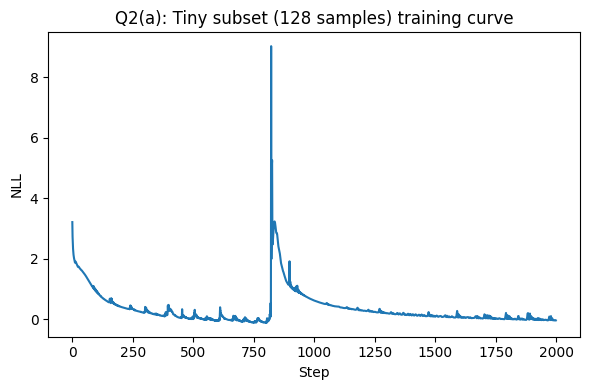

Saved figs/Figure2a.pdf


In [ ]:
SEED = 42
N_TINY_STEPS = 2000
LR = 1e-3

x_tiny = x_train[:128]

torch.manual_seed(SEED)
flow_tiny = Flow(dim=2, hidden=128, n_layers=8)
optimizer_tiny = torch.optim.Adam(flow_tiny.parameters(), lr=LR)

tiny_losses = []
for step in range(N_TINY_STEPS):
    loss = -flow_tiny.log_prob(x_tiny).mean()
    optimizer_tiny.zero_grad()
    loss.backward()
    optimizer_tiny.step()
    tiny_losses.append(loss.item())
    if (step + 1) % 500 == 0:
        print(f"Step {step+1}/{N_TINY_STEPS}, NLL: {loss.item():.4f}")

# Final NLL evaluated on the full tiny set
flow_tiny.eval()
with torch.no_grad():
    tinyset_final_nll = -flow_tiny.log_prob(x_tiny).mean().item()
print(f"\nFinal tiny-set NLL: {tinyset_final_nll:.4f}")

# --- Figure 2a ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tiny_losses)
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Q2(a): Tiny subset (128 samples) training curve")
fig.tight_layout()
fig.savefig("figs/Figure2a.pdf")
plt.show()
print("Saved figs/Figure2a.pdf")

### (b) + (c) Full training

Train on the full `data/moons_train.csv` with:
- Cosine annealing LR schedule
- Validation loss tracking against `data/moons_val.csv`
- Final checkpoint saved to `checkpoints/flow_full.pt`
- Training log saved to `logs/training_curves.json`

Record final train, validation, and test NLL in `results.json`.

Step 500/5000, Train NLL: 0.2407, Val NLL: 0.3913
Step 1000/5000, Train NLL: 0.1719, Val NLL: 0.4044
Step 1500/5000, Train NLL: 0.1508, Val NLL: 0.4012
Step 2000/5000, Train NLL: 0.1366, Val NLL: 0.4187
Step 2500/5000, Train NLL: 0.1219, Val NLL: 0.4180
Step 3000/5000, Train NLL: 0.1144, Val NLL: 0.4381
Step 3500/5000, Train NLL: 0.0990, Val NLL: 0.4601
Step 4000/5000, Train NLL: 0.0937, Val NLL: 0.4651
Step 4500/5000, Train NLL: 0.0886, Val NLL: 0.4705
Step 5000/5000, Train NLL: 0.0876, Val NLL: 0.4711

Final Train NLL: 0.0876
Final Val NLL:   0.4711
Final Test NLL:  2.4029
Saved checkpoints/flow_full.pt
Saved logs/training_curves.json


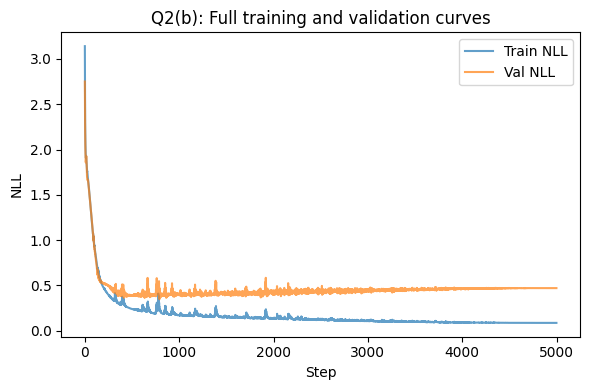

Saved figs/Figure2c.pdf
Updated results.json with training metrics


In [ ]:
N_FULL_STEPS = 5000

# Load validation and test data
val_data = np.loadtxt("data/moons_val.csv", delimiter=",", skiprows=1)
test_data = np.loadtxt("data/moons_test.csv", delimiter=",", skiprows=1)
x_val = torch.tensor(val_data[:, :2], dtype=torch.float32)
x_test = torch.tensor(test_data[:, :2], dtype=torch.float32)

# Fresh flow for full training
torch.manual_seed(SEED)
flow_full = Flow(dim=2, hidden=128, n_layers=8)
optimizer_full = torch.optim.Adam(flow_full.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_full, T_max=N_FULL_STEPS)

full_losses = []
full_val_losses = []

for step in range(N_FULL_STEPS):
    flow_full.train()
    loss = -flow_full.log_prob(x_train).mean()
    optimizer_full.zero_grad()
    loss.backward()
    optimizer_full.step()
    scheduler.step()

    full_losses.append(loss.item())

    # Validation loss every step (cheap: only 100 points)
    flow_full.eval()
    with torch.no_grad():
        val_loss = -flow_full.log_prob(x_val).mean().item()
    full_val_losses.append(val_loss)

    if (step + 1) % 500 == 0:
        print(f"Step {step+1}/{N_FULL_STEPS}, Train NLL: {loss.item():.4f}, Val NLL: {val_loss:.4f}")

# --- Final NLLs ---
flow_full.eval()
with torch.no_grad():
    final_train_nll = -flow_full.log_prob(x_train).mean().item()
    final_val_nll = -flow_full.log_prob(x_val).mean().item()
    final_test_nll = -flow_full.log_prob(x_test).mean().item()

print(f"\nFinal Train NLL: {final_train_nll:.4f}")
print(f"Final Val NLL:   {final_val_nll:.4f}")
print(f"Final Test NLL:  {final_test_nll:.4f}")

# --- Save checkpoint ---
os.makedirs("checkpoints", exist_ok=True)
torch.save({
    "state_dict": flow_full.state_dict(),
    "config": {"dim": 2, "hidden": 128, "n_layers": 8},
    "seed": SEED,
}, "checkpoints/flow_full.pt")
print("Saved checkpoints/flow_full.pt")

# --- Save training curves log ---
os.makedirs("logs", exist_ok=True)
with open("logs/training_curves.json", "w") as f:
    json.dump({
        "tiny_loss": tiny_losses,
        "full_loss": full_losses,
        "full_val_loss": full_val_losses,
    }, f)
print("Saved logs/training_curves.json")

# --- Figure 2c ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(full_losses, label="Train NLL", alpha=0.7)
ax.plot(full_val_losses, label="Val NLL", alpha=0.7)
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Q2(b): Full training and validation curves")
ax.legend()
fig.tight_layout()
fig.savefig("figs/Figure2c.pdf")
plt.show()
print("Saved figs/Figure2c.pdf")

# --- Update results.json ---
with open("results.json", "r") as f:
    results = json.load(f)

results["training"] = {
    "tinyset_final_nll": tinyset_final_nll,
    "final_train_nll": final_train_nll,
    "final_val_nll": final_val_nll,
    "final_test_nll": final_test_nll,
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Updated results.json with training metrics")